In [1]:
print("Hello, ML world!")

Hello, ML world!


In [2]:
import pandas as pd

In [3]:
# Read the CSV file into a pandas DataFrame
df_master = pd.read_csv("products.csv")

In [4]:
# Preview the data
print(f"Total products loaded: {len(df_master)}")
print(f"Columns: {df_master.columns.tolist()}")
df_master

Total products loaded: 12
Columns: ['name', 'description', 'sku', 'category']


,name,description,sku,category
0,Samsung 55 Inch QLED TV,4K Ultra HD Smart TV with Quantum Dot technolo...,SAM-TV-55Q,Electronics
1,Sony WH-1000XM5 Headphones,Wireless noise cancelling headphones with 30 h...,SNY-HP-XM5,Electronics
2,Nike Air Max 270 Running Shoes,Lightweight athletic shoes with Air Max cushio...,NKE-SH-AM270,Footwear
3,Apple MacBook Pro 14 inch,Laptop with M3 Pro chip 18GB RAM and 512GB SSD...,APL-LT-MBP14,Computers
4,Instant Pot Duo 7-in-1,Electric pressure cooker slow cooker rice cook...,INS-KT-DUO7,Kitchen
5,Levis 501 Original Jeans,Classic straight fit denim jeans with button f...,LEV-JN-501,Apparel
6,Dyson V15 Detect Vacuum,Cordless stick vacuum with laser dust detectio...,DYS-VC-V15,Home Appliances
7,Canon EOS R6 Mark II Camera,Full frame mirrorless camera with 40fps burst ...,CAN-CM-R6M2,Electronics
8,Adidas Ultraboost 23 Sneakers,Premium running shoes with Boost midsole and P...,ADI-SH-UB23,Footwear
9,KitchenAid Stand Mixer 5 Quart,Tilt-head stand mixer with 10 speeds and stain...,KAD-KT-SM5Q,Kitchen


In [6]:
import pandas as pd
import numpy as np
import random
import re
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

from thefuzz import fuzz
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

random.seed(42)
np.random.seed(42)

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [25]:
def introduce_noise(text):
    """Randomly corrupts text to simulate real-world dirty data."""
    
    # 30% chance to return the text as-is (not every duplicate is messy)
    if random.random() > 0.7:
        return text
    
    # Pick one random corruption to apply
    ops = [
        lambda t: t.lower(),                                    # "Samsung TV" → "samsung tv"
        lambda t: t.upper(),                                    # "Samsung TV" → "SAMSUNG TV"
        lambda t: t.replace(" ", "-"),                          # "Samsung TV" → "Samsung-TV"
        lambda t: t.replace("inch", "in"),                      # "55 inch" → "55 in"
        lambda t: t.replace("Wireless", "Wrlss"),               # abbreviation
        lambda t: t[:-2],                                       # drop last 2 chars
        lambda t: t.replace(" ", "  "),                         # extra spaces
    ]
    
    return random.choice(ops)(text)


def mangle_sku(sku):
    """Slightly alters SKU to simulate supplier variation."""
    ops = [
        lambda s: s.replace("-", ""),      # "SAM-TV-55Q" → "SAMTV55Q"
        lambda s: s.lower(),               # "SAM-TV-55Q" → "sam-tv-55q"
        lambda s: s + "-A",                # "SAM-TV-55Q" → "SAM-TV-55Q-A"
        lambda s: s,                       # keep original
    ]
    return random.choice(ops)(sku)


# Now generate duplicate records from the master data
records = []
duplicate_pairs = set()   # stores which record IDs are true duplicates
record_id = 1

for _, product in df_master.iterrows():
    original_id = record_id
    
    # Add the original clean record
    records.append({
        "record_id": record_id,
        "name": product["name"],
        "description": product["description"],
        "sku": product["sku"],
        "category": product["category"]
    })
    record_id += 1

    # Add 1 or 2 noisy duplicate versions of the same product
    for _ in range(random.choice([1, 2])):
        dup_id = record_id
        records.append({
            "record_id": dup_id,
            "name": introduce_noise(product["name"]),
            "description": introduce_noise(product["description"]),
            "sku": mangle_sku(product["sku"]),
            "category": product["category"]
        })
        duplicate_pairs.add((min(original_id, dup_id), max(original_id, dup_id)))
        record_id += 1

# Convert to DataFrame
df = pd.DataFrame(records)

# After building records and duplicate_pairs, verify by checking identical records
print("Verifying ground truth...")
print(f"Duplicate pairs tracked: {len(duplicate_pairs)}")

# Find any pairs we might have missed
missed = []
for pair in candidate_pairs:
    id1, id2 = pair
    r1 = df_idx.loc[id1]
    r2 = df_idx.loc[id2]
    if (r1['name'] == r2['name'] and 
        r1['sku'].upper().replace('-','') == r2['sku'].upper().replace('-','')):
        if pair not in duplicate_pairs:
            missed.append(pair)
            print(f"  Found missed duplicate pair: {pair}")
            print(f"  name: {r1['name']} vs {r2['name']}")
            print(f"  sku : {r1['sku']} vs {r2['sku']}")

# Add missed pairs to ground truth
for pair in missed:
    duplicate_pairs.add(pair)

print(f"Updated duplicate pairs: {len(duplicate_pairs)}")

print(f"Original products:       {len(df_master)}")
print(f"Total records (with dups): {len(df)}")
print(f"Ground truth dup pairs:  {len(duplicate_pairs)}")
df.head(10)

Verifying ground truth...
Duplicate pairs tracked: 16
  Found missed duplicate pair: (17, 18)
  name: Canon EOS R6 Mark II Camera vs Canon EOS R6 Mark II Camera
  sku : CAN-CM-R6M2 vs CAN-CM-R6M2
  Found missed duplicate pair: (24, 25)
  name: Bose SoundLink Flex Speaker vs Bose SoundLink Flex Speaker
  sku : BSE-SP-SLF vs bse-sp-slf
  Found missed duplicate pair: (24, 26)
  name: Bose SoundLink Flex Speaker vs Bose SoundLink Flex Speaker
  sku : BSE-SP-SLF vs BSESPSLF
  Found missed duplicate pair: (25, 26)
  name: Bose SoundLink Flex Speaker vs Bose SoundLink Flex Speaker
  sku : bse-sp-slf vs BSESPSLF
  Found missed duplicate pair: (14, 16)
  name: Dyson V15 Detect Vacuum vs Dyson V15 Detect Vacuum
  sku : DYS-VC-V15 vs DYSVCV15
  Found missed duplicate pair: (15, 16)
  name: Dyson V15 Detect Vacuum vs Dyson V15 Detect Vacuum
  sku : DYSVCV15 vs DYSVCV15
Updated duplicate pairs: 22
Original products:       12
Total records (with dups): 28
Ground truth dup pairs:  22


,record_id,name,description,sku,category
0,1,Samsung 55 Inch QLED TV,4K Ultra HD Smart TV with Quantum Dot technolo...,SAM-TV-55Q,Electronics
1,2,Samsung 55 Inch QLED TV,4K Ultra HD Smart TV with Quantum Dot technolo...,SAM-TV-55Q-A,Electronics
2,3,Sony WH-1000XM5 Headphones,Wireless noise cancelling headphones with 30 h...,SNY-HP-XM5,Electronics
3,4,Sony WH-1000XM5 Headphon,Wireless-noise-cancelling-headphones-with-30-h...,SNY-HP-XM5,Electronics
4,5,Sony WH-1000XM5 Headphon,Wireless-noise-cancelling-headphones-with-30-h...,SNYHPXM5,Electronics
5,6,Nike Air Max 270 Running Shoes,Lightweight athletic shoes with Air Max cushio...,NKE-SH-AM270,Footwear
6,7,Nike Air Max 270 Running Shoes,Lightweight athletic shoes with Air Max cushio...,NKESHAM270,Footwear
7,8,Apple MacBook Pro 14 inch,Laptop with M3 Pro chip 18GB RAM and 512GB SSD...,APL-LT-MBP14,Computers
8,9,APPLE MACBOOK PRO 14 INCH,Laptop with M3 Pro chip 18GB RAM and 512GB SSD...,APLLTMBP14,Computers
9,10,Instant Pot Duo 7-in-1,Electric pressure cooker slow cooker rice cook...,INS-KT-DUO7,Kitchen


In [10]:
print(records["name"])

TypeError: list indices must be integers or slices, not str

In [11]:
print(df["name"])

0            Samsung 55 Inch QLED TV
1            Samsung 55 Inch QLED TV
2         Sony WH-1000XM5 Headphones
3         SONY WH-1000XM5 HEADPHONES
4         Sony WH-1000XM5 Headphones
5     Nike Air Max 270 Running Shoes
6     Nike Air Max 270 Running Shoes
7          Apple MacBook Pro 14 inch
8            Apple MacBook Pro 14 in
9             Instant Pot Duo 7-in-1
10            INSTANT POT DUO 7-IN-1
11          Levis 501 Original Jeans
12          LEVIS 501 ORIGINAL JEANS
13           Dyson V15 Detect Vacuum
14           Dyson V15 Detect Vacuum
15           Dyson V15 Detect Vacuum
16       Canon EOS R6 Mark II Camera
17       Canon EOS R6 Mark II Camera
18     Adidas Ultraboost 23 Sneakers
19     adidas ultraboost 23 sneakers
20    KitchenAid Stand Mixer 5 Quart
21      KitchenAid Stand Mixer 5 Qua
22    KitchenAid-Stand-Mixer-5-Quart
23       Bose SoundLink Flex Speaker
24       Bose SoundLink Flex Speaker
25       Bose SoundLink Flex Speaker
26                Dell XPS 15 Laptop
2

In [26]:
def normalize(text):
    """Cleans and standardizes any text field."""
    
    if pd.isna(text):           # handle empty/null values
        return ""
    
    text = str(text).lower()                    # SAMSUNG TV → samsung tv
    text = re.sub(r'[^\w\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # collapse extra spaces
    
    return text


def normalize_sku(sku):
    """Standardizes SKU by removing special characters and uppercasing."""
    return re.sub(r'[^A-Z0-9]', '', str(sku).upper())  # SAM-TV-55Q → SAMTV55Q


# Apply normalization to every row in the DataFrame
df['name_norm'] = df['name'].apply(normalize)
df['desc_norm'] = df['description'].apply(normalize)
df['sku_norm']  = df['sku'].apply(normalize_sku)
df['cat_norm']  = df['category'].apply(normalize)

print("Normalization complete!")
print(f"Total columns now: {df.columns.tolist()}")
df[['name', 'name_norm', 'sku', 'sku_norm','cat_norm']].head(len(df))

Normalization complete!
Total columns now: ['record_id', 'name', 'description', 'sku', 'category', 'name_norm', 'desc_norm', 'sku_norm', 'cat_norm']


,name,name_norm,sku,sku_norm,cat_norm
0,Samsung 55 Inch QLED TV,samsung 55 inch qled tv,SAM-TV-55Q,SAMTV55Q,electronics
1,Samsung 55 Inch QLED TV,samsung 55 inch qled tv,SAM-TV-55Q-A,SAMTV55QA,electronics
2,Sony WH-1000XM5 Headphones,sony wh 1000xm5 headphones,SNY-HP-XM5,SNYHPXM5,electronics
3,Sony WH-1000XM5 Headphon,sony wh 1000xm5 headphon,SNY-HP-XM5,SNYHPXM5,electronics
4,Sony WH-1000XM5 Headphon,sony wh 1000xm5 headphon,SNYHPXM5,SNYHPXM5,electronics
5,Nike Air Max 270 Running Shoes,nike air max 270 running shoes,NKE-SH-AM270,NKESHAM270,footwear
6,Nike Air Max 270 Running Shoes,nike air max 270 running shoes,NKESHAM270,NKESHAM270,footwear
7,Apple MacBook Pro 14 inch,apple macbook pro 14 inch,APL-LT-MBP14,APLLTMBP14,computers
8,APPLE MACBOOK PRO 14 INCH,apple macbook pro 14 inch,APLLTMBP14,APLLTMBP14,computers
9,Instant Pot Duo 7-in-1,instant pot duo 7 in 1,INS-KT-DUO7,INSKTDUO7,kitchen


In [15]:
candidate_pairs = []

for category, group in df.groupby('cat_norm'):
    ids = group['record_id'].tolist()
    for id1, id2 in itertools.combinations(ids, 2):
        candidate_pairs.append((min(id1, id2), max(id1, id2)))

total_possible = len(df) * (len(df) - 1) // 2

print(f"Total possible pairs (no blocking):  {total_possible}")
print(f"Candidate pairs (after blocking):    {len(candidate_pairs)}")
print(f"Reduction:                           {100*(1 - len(candidate_pairs)/total_possible):.1f}%")
print(f"Ground truth pairs captured:         {len(set(candidate_pairs) & duplicate_pairs)} / {len(duplicate_pairs)}")

Total possible pairs (no blocking):  378
Candidate pairs (after blocking):    71
Reduction:                           81.2%
Ground truth pairs captured:         16 / 16


In [27]:
# Index df by record_id for fast lookup
df_idx = df.set_index('record_id')

def compute_features(id1, id2):
    # Fetch both records
    r1 = df_idx.loc[id1]
    r2 = df_idx.loc[id2]

    # Extract normalized fields
    name1, name2 = r1['name_norm'], r2['name_norm']
    desc1, desc2 = r1['desc_norm'], r2['desc_norm']
    sku1,  sku2  = r1['sku_norm'],  r2['sku_norm']

    return {
        'id1':             id1,
        'id2':             id2,
        'name_ratio':      fuzz.ratio(name1, name2) / 100,
        'name_token_sort': fuzz.token_sort_ratio(name1, name2) / 100,
        'name_partial':    fuzz.partial_ratio(name1, name2) / 100,
        'desc_ratio':      fuzz.ratio(desc1, desc2) / 100,
        'desc_token_sort': fuzz.token_sort_ratio(desc1, desc2) / 100,
        'sku_ratio':       fuzz.ratio(sku1, sku2) / 100,
        'sku_exact':       int(sku1 == sku2),
    }

# Compute features for ALL candidate pairs
print("Computing features for all candidate pairs...")
features = [compute_features(id1, id2) for id1, id2 in candidate_pairs]
pairs_df = pd.DataFrame(features)

# Add ground truth label — 1 if real duplicate, 0 if not
pairs_df['is_duplicate'] = pairs_df.apply(
    lambda row: 1 if (row['id1'], row['id2']) in duplicate_pairs else 0, axis=1
)

print(f"Feature matrix shape:  {pairs_df.shape}")
print(f"Duplicate pairs:       {pairs_df['is_duplicate'].sum()}")
print(f"Non-duplicate pairs:   {(pairs_df['is_duplicate']==0).sum()}")
pairs_df.head(8)

Computing features for all candidate pairs...
Feature matrix shape:  (71, 10)
Duplicate pairs:       16
Non-duplicate pairs:   55


,id1,id2,name_ratio,name_token_sort,name_partial,desc_ratio,desc_token_sort,sku_ratio,sku_exact,is_duplicate
0,12,13,1.00,1.00,1.00,0.98,0.98,1.00,1,1
1,8,9,1.00,1.00,1.00,1.00,1.00,1.00,1,1
2,8,27,0.28,0.37,0.33,0.47,0.54,0.48,0,0
3,8,28,0.28,0.37,0.33,0.47,0.54,0.50,0,0
4,9,27,0.28,0.37,0.33,0.47,0.54,0.48,0,0
5,9,28,0.28,0.37,0.33,0.47,0.54,0.50,0,0
6,27,28,1.00,1.00,1.00,1.00,1.00,0.95,0,0
7,1,2,1.00,1.00,1.00,1.00,1.00,0.94,0,1


In [28]:
# See the actual column names
print(pairs_df.columns.tolist())

# See a duplicate pair vs a non-duplicate pair side by side
print("\n--- A REAL DUPLICATE PAIR ---")
print(pairs_df[pairs_df['is_duplicate'] == 1].head(1).to_string())

print("\n--- A NON-DUPLICATE PAIR ---")
print(pairs_df[pairs_df['is_duplicate'] == 0].head(1).to_string())

['id1', 'id2', 'name_ratio', 'name_token_sort', 'name_partial', 'desc_ratio', 'desc_token_sort', 'sku_ratio', 'sku_exact', 'is_duplicate']

--- A REAL DUPLICATE PAIR ---
   id1  id2  name_ratio  name_token_sort  name_partial  desc_ratio  desc_token_sort  sku_ratio  sku_exact  is_duplicate
0   12   13         1.0              1.0           1.0        0.98             0.98        1.0          1             1

--- A NON-DUPLICATE PAIR ---
   id1  id2  name_ratio  name_token_sort  name_partial  desc_ratio  desc_token_sort  sku_ratio  sku_exact  is_duplicate
2    8   27        0.28             0.37          0.33        0.47             0.54       0.48          0             0


In [29]:
def show_pair(row):
    r1 = df_idx.loc[row['id1']]
    r2 = df_idx.loc[row['id2']]
    print(f"Record {int(row['id1'])}  name : {r1['name']}")
    print(f"Record {int(row['id2'])}  name : {r2['name']}")
    print(f"Record {int(row['id1'])}  sku  : {r1['sku']}")
    print(f"Record {int(row['id2'])}  sku  : {r2['sku']}")
    print(f"--- Similarity Scores ---")
    print(f"name_ratio      : {row['name_ratio']:.2f}")
    print(f"name_token_sort : {row['name_token_sort']:.2f}")
    print(f"name_partial    : {row['name_partial']:.2f}")
    print(f"desc_ratio      : {row['desc_ratio']:.2f}")
    print(f"desc_token_sort : {row['desc_token_sort']:.2f}")
    print(f"sku_ratio       : {row['sku_ratio']:.2f}")
    print(f"sku_exact       : {int(row['sku_exact'])}")
    print(f"is_duplicate    : {int(row['is_duplicate'])}")

print("=" * 50)
print("REAL DUPLICATE PAIR")
print("=" * 50)
show_pair(pairs_df[pairs_df['is_duplicate'] == 1].iloc[0])

print()
print("=" * 50)
print("NON DUPLICATE PAIR")
print("=" * 50)
show_pair(pairs_df[pairs_df['is_duplicate'] == 0].iloc[0])

REAL DUPLICATE PAIR
Record 12  name : Levis 501 Original Jeans
Record 13  name : Levis 501 Original Jeans
Record 12  sku  : LEV-JN-501
Record 13  sku  : LEVJN501
--- Similarity Scores ---
name_ratio      : 1.00
name_token_sort : 1.00
name_partial    : 1.00
desc_ratio      : 0.98
desc_token_sort : 0.98
sku_ratio       : 1.00
sku_exact       : 1
is_duplicate    : 1

NON DUPLICATE PAIR
Record 8  name : Apple MacBook Pro 14 inch
Record 27  name : DELL XPS 15 LAPTOP
Record 8  sku  : APL-LT-MBP14
Record 27  sku  : DEL-LT-XPS15-A
--- Similarity Scores ---
name_ratio      : 0.28
name_token_sort : 0.37
name_partial    : 0.33
desc_ratio      : 0.47
desc_token_sort : 0.54
sku_ratio       : 0.48
sku_exact       : 0
is_duplicate    : 0


In [30]:
# Define features and target
feature_cols = ['name_ratio', 'name_token_sort', 'name_partial', 
                'desc_ratio', 'desc_token_sort', 'sku_ratio', 'sku_exact']

X = pairs_df[feature_cols]   # input features  (the 7 similarity scores)
y = pairs_df['is_duplicate'] # target label     (1 = duplicate, 0 = not)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

print(f"Total pairs:        {len(X)}")
print(f"Training pairs:     {len(X_train)}")
print(f"Testing pairs:      {len(X_test)}")

# Train the model
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

print("\nModel trained successfully!")

Total pairs:        71
Training pairs:     53
Testing pairs:      18

Model trained successfully!


In [31]:
# Make predictions on test set
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Duplicate', 'Duplicate']))

Classification Report:
               precision    recall  f1-score   support

Non-Duplicate       1.00      1.00      1.00        14
    Duplicate       1.00      1.00      1.00         4

     accuracy                           1.00        18
    macro avg       1.00      1.00      1.00        18
 weighted avg       1.00      1.00      1.00        18



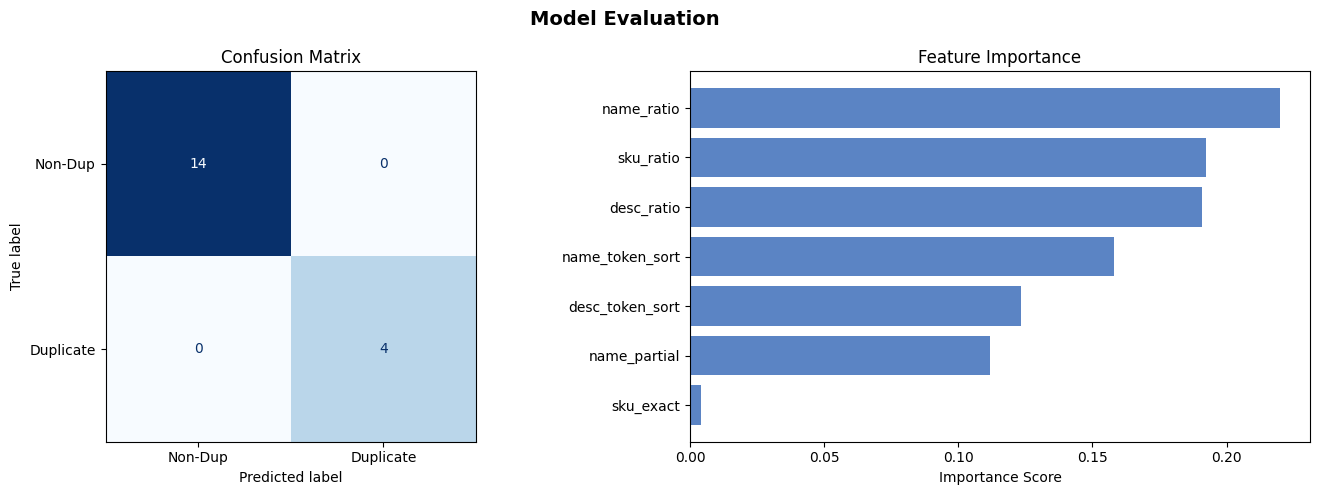

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# --- Chart 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Dup', 'Duplicate'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontsize=12)

# --- Chart 2: Feature Importance ---
importances = clf.feature_importances_
feature_cols = ['name_ratio', 'name_token_sort', 'name_partial',
                'desc_ratio', 'desc_token_sort', 'sku_ratio', 'sku_exact']
sorted_idx = np.argsort(importances)

ax2.barh(
    [feature_cols[i] for i in sorted_idx],
    importances[sorted_idx],
    color='#5B84C4'
)
ax2.set_title('Feature Importance', fontsize=12)
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [33]:
# Get the test set with predictions added
X_test_copy = X_test.copy()
X_test_copy['actual']     = y_test.values
X_test_copy['predicted']  = y_pred
X_test_copy['confidence'] = y_prob

# Find wrongly predicted pairs
wrong = X_test_copy[X_test_copy['actual'] != X_test_copy['predicted']]

print(f"Total wrong predictions: {len(wrong)}")
print()

for _, row in wrong.iterrows():
    # Get record IDs from pairs_df
    pair_row = pairs_df.iloc[row.name]
    id1 = int(pair_row['id1'])
    id2 = int(pair_row['id2'])
    
    r1 = df_idx.loc[id1]
    r2 = df_idx.loc[id2]
    
    print("=" * 55)
    print(f"Record {id1}  name : {r1['name']}")
    print(f"Record {id2}  name : {r2['name']}")
    print(f"Record {id1}  sku  : {r1['sku']}")
    print(f"Record {id2}  sku  : {r2['sku']}")
    print(f"---")
    print(f"Actual    : {'Duplicate' if row['actual'] == 1 else 'Non-Duplicate'}")
    print(f"Predicted : {'Duplicate' if row['predicted'] == 1 else 'Non-Duplicate'}")
    print(f"Confidence: {row['confidence']:.0%}")
    print(f"---")
    print(f"name_ratio      : {row['name_ratio']:.2f}")
    print(f"name_token_sort : {row['name_token_sort']:.2f}")
    print(f"name_partial    : {row['name_partial']:.2f}")
    print(f"sku_ratio       : {row['sku_ratio']:.2f}")
    print(f"sku_exact       : {int(row['sku_exact'])}")
    print()

Total wrong predictions: 0



In [24]:
print((25, 26) in duplicate_pairs)
print((26, 25) in duplicate_pairs)

False
False
